# Лекция.  Регуляризация

In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning) 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns
sns.set_style("whitegrid")

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler

from sklearn.preprocessing import PolynomialFeatures


from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier

from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import BayesianRidge

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import confusion_matrix

## § 1. Ridge-регуляризация

### 1.1. Вспоминаем алгебру 

Начнем с самого простого вопроса: как решается крамеровская система? Правильно: 1) метод Крамера (крамеровские системы потому так и называются, что их можно решить методом Крамера), 2) метод Гаусса (он универсальный, куда же без него) и 3) ненавидимый всеми студентами метод матричного обращения. Он-то нам и нужен.

Если у нас есть система

$$
Xw=y
$$

где $X$ — матрица коэффициентов, $w$ — столбец переменных, а $y$ — столбец свободных членов, то столбец переменных выражается при помощи умножения на обратную матрицу:

$$
w = X^{-1}y
$$

Одно действие и решение готово. Студенты не любят этот метод, потому что приходится вычислять обратную матрицу, а это муторно. А алгоритму все равно, он это делает легко и непринужденно. 

Теперь давайте представим, что $X$ — это не квадратная матрица, а прямоугольная. Причем вытянута она сверху вниз (число строк $n$ у нее больше, чем число столбцов $m$). Тогда  никакой обратной матрицы $X^{-1}$ не существует, и, казалось бы, ситуация безвыходная.

Но можно поступить вот как. Умножим наше равенство на $X^{\rm T}$ слева:

$$
X^{\rm T}Xw=X^{\rm T}y
$$

Матрица $X^{\rm T}X$ — это квадратная матрица $m\times m$. А если мы дополнительно предположим, что все столбцы матрицы $X$ линейно независимы (или, другими словами, что $X$ — это матрица полного ранга, или, другими словами, что ${\rm rank} X = m$), то тогда матрица $X^{\rm T}X$ невырождена, а значит, у нее есть обратная! На самом деле она не только невырождена, она еще и симметрична и положительно определена, но это для нас пока не важно. Важно, что можно посчитать обратную.

Умножаем на обратную матрицу слева:

$$
(X^{\rm T}X)^{-1}X^{\rm T}Xw=(X^{\rm T}X)^{-1}X^{\rm T}y
$$

и мы высвободили вектор переменной $w$  в левой части:

$$
w=(X^{\rm T}X)^{-1}X^{\rm T}y
$$

Это и есть псевдорешение переопределенной системы. То самое, которое определяет коэффициенты линейной регрессии. Это, кстати, объясняет, почему LinearRegression так быстро учится. Потому что все ее обучение сводится к применению этой формулы, то есть, обучение проходит в одно действие.

Теперь мы можем вручную решить задачу линейной регрессии, не прибегая к методу `LinearRegression` из sklearn:

In [2]:
X = np.array([[1, 2, 1],
              [2, 1, 1],
              [3, 3, 1],
              [4, 5, 1],
              [5, 4, 1]])

y = np.array([[3.002],
              [2.999],
              [6.001],
              [8.999],
              [9.001]])

A = np.dot(X.T, X)
A_inv = np.linalg.inv(A)
B = np.dot(A_inv, X.T)

w_lr = np.dot(B, y)

print('w_lr =')
print(w_lr)

w_lr =
[[9.99666667e-01]
 [1.00016667e+00]
 [9.00000000e-04]]


Надеюсь, вы помните, зачем мы добавили столбец из единиц? Правильно, чтобы получить свободный член. Ну, что ж. Решение вполне приличное. Действительно: таргет — это примерно сумма предикторов, соответственно, коэффициенты регрессии — это примерно единицы, а свободный член — примерно ноль.

### 1.2. Мультиколлинеарность

Теперь давайте предположим, что среди столбцов матрицы $X$ есть сильно коррелирующие. Тогда столбцы этой матрицы окажутся почти линейно зависимыми (разумеется, не в алгебраическом, а в статистическом смысле, это называется — мультиколлинеарность). А матрица $X^{\rm T}X$ окажется почти вырожденной в том смысле, что ее определитель будет очень близок к нулю. Такие матрицы называются плохо обратимыми. Не потому, что обратную трудно посчитать (она считается точно так же). А потому, что обратная матрица будет обладать огромными элементами. 

Действительно, вспомним формулу для вычисления обратных матриц:

$$
A^{-1} = \frac{1}{|A|} (A^*)^{\rm T}
$$

Если определитель близок к нулю, то после деления на определитель получится матрица с огромными компонентами.

Казалось бы — ну и что? Большие, маленькие — какая разница? Но разница есть и она существенна. Дело в том, что если матрица плохо обратима, то при небольших изменениях правой части мы будем получать совершенно разные результаты (именно поэтому она плохо обратима, а не потому, что ее трудно обратить).

Вернемся к нашему примеру. Пусть второй столбец нашей матрицы — это примерно первый (они сильно коррелируют). А таргет — это примерно сумма предикторов. Делаем ровно то же самое, что и выше:

In [3]:
X = np.array([[1, 1.001, 1],
              [2, 1.999, 1],
              [3, 3.000, 1],
              [4, 4.001, 1],
              [5, 4.999, 1]])

y = np.array([[2.001],
              [4.001],
              [6.000],
              [8.001],
              [9.999]])

A = np.dot(X.T, X)
A_inv = np.linalg.inv(A)
B = np.dot(A_inv, X.T)

w_lr = np.dot(B, y)
print('w_lr =')
print(w_lr)

w_lr =
[[1.66633333e+00]
 [3.33333331e-01]
 [1.40000000e-03]]


Ну... наверное можно и так... вообще-то мы закладывали ту же логику в  данные: таргет — это примерно сумма предикторов. Но решение таково, каково оно есть: теперь коэффициенты при предикторах не равноправны: первый предиктор имеет больший вес, и не просто больший, а примерно в 5 раз больший.

Но это еще полбеды. Беда у нас только начинается. Возьмем новую правую часть, не сильно отличающуюся от старой (разница примерно на единицу в последней координате). 

И что мы видим?

In [4]:
y_new = np.array([[2.001],
                  [4.001],
                  [6.000],
                  [8.001],
                  [9]])

w_new_lr = np.dot(B, y_new)

print('w_new_lr =')
print(w_new_lr)

w_new_lr =
[[-165.00016637]
 [ 166.83333303]
 [   0.3011    ]]


Мы видим какой-то бред. Вот такую логику мы точно не закладывали в наши данные. Мы сказали: возьмите два предиктора и сложите их, и вы получите примерно таргет. Но мы не говорили: умножьте первый предиктор на -165, а второй на 167.

И все из-за того, что матрица $X^{\rm T}X$ плохо обратима. Давайте вычислим разность между старыми коэффициентами регрессии и новыми (это число нам еще понадобится):

In [5]:
delta_lr = (((w_lr - w_new_lr)**2).sum())**0.5
print('delta_lr =', delta_lr)

delta_lr = 235.5845110441021


### 1.3. Ридж

Борьба с плохой обратимостью матрицы $X^{\rm T}X$ осуществляется так:

$$
w=(X^{\rm T}X + \alpha E)^{-1}X^{\rm T}y\,\qquad \alpha \geq 0
$$

Этот прием и называется ридж-регуляризацией. Его смысл в том, что если определитель матрицы — это почти ноль, то среди собственных значений этой матрицы есть хотя бы одно почти нулевое. Причем все собственные значения — положительны (вспомним, что наша матрица положительно определена!). А после прибавления к главной диагонали положительного $\alpha$ все собственные значения увеличатся на $\alpha$, и тем самым, мы отодвинем определитель от нуля. 

Просто как все гениальное. Ну что ж... Попробуем. Для простоты положим $\alpha = 1$. Поехали:

In [6]:
E = np.array([[1, 0, 0],
              [0, 1, 0],
              [0, 0, 1]])

A = np.dot(X.T, X)
A_inv = np.linalg.inv(A + E)
B = np.dot(A_inv, X.T)
B

y = np.array([[2.001],
              [4.001],
              [6.000],
              [8.001],
              [9.999]])

w_ridge = np.dot(B, y)
w_ridge

array([[0.97224789],
       [0.97213476],
       [0.13937671]])

Это, конечно не буквальное воспроизведение нашей логики, но лучше, чем было:  как ни крути, коэффициентов при предикторах близки к единице, а свободный член близок к нулю.

А теперь попробуем новую правую часть:

In [7]:
y_new = np.array([[2.001],
                  [4.001],
                  [6.000],
                  [8.001],
                  [9]])

w_new_ridge = np.dot(B, y_new)
w_new_ridge

array([[0.90251818],
       [0.90312686],
       [0.31972075]])

Разница, конечно, есть. Но по сравнению с тем, что было — она микроскопична! Вычислим длину разности:

In [8]:
delta_ridge = (((w_ridge - w_new_ridge)**2).sum())**0.5
delta_ridge

0.20530050631518657

А теперь сравним изменения коэффициентов линейно и ридж-регрессии:

In [9]:
delta_lr/delta_ridge

1147.5106188117343

То есть, при одном и том же незначительном изменении таргета, изменения коэффициентов линейной регрессии в 1148 раз больше, чем изменения коэффициентов ридж-регрессии. Стабильность коэффициентов повысилась больше чем на три порядка.

### 1.4. Менее игрушечный пример

Пусть у нас есть данные о квартирах, про которые мы знаем их площадь, число комнат и стоимость ~~в мешках золота~~ в тысячах рублей:

In [10]:
df = pd.read_csv('data/area_rooms.csv')
print(df)

          area  rooms         price
0    63.708611    2.0   6477.362016
1   115.564288    4.0  12483.195796
2    95.879455    3.0   9605.617060
3    83.879264    3.0   9898.010941
4    44.041678    1.0   4767.001438
..         ...    ...           ...
95   74.441604    2.0   6826.229292
96   77.045955    3.0   8436.177341
97   68.478692    2.0   6952.985696
98   32.287721    1.0   2788.017815
99   39.710228    1.0   4252.074580

[100 rows x 3 columns]


Площадь и количество комнат сильно коррелируют: чем больше площадь, тем больше комнат:

In [11]:
corr_matr = df.drop(columns = ['price']).corr()
print(corr_matr)

           area     rooms
area   1.000000  0.954432
rooms  0.954432  1.000000


И  коль скоро мы видим высокую корреляцию, пора готовиться к плохой обратимости. Разделяем данные на предикторы и таргет и разбиваем на обучающую и тестовую выборки:

In [12]:
X = df.drop(columns = ['price'])
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

#### Обычная линейная регрессия

In [13]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_train_pred_lr = lr.predict(X_train)
y_test_pred_lr = lr.predict(X_test)

print('Коэффициенты: area =', round(lr.coef_[0], 2), ', rooms =', round(lr.coef_[1], 2))
print('Свободный член:', round(lr.intercept_, 2))
print('R² на train:', round(r2_score(y_train, y_train_pred_lr), 4))
print('R² на test:',  round(r2_score(y_test, y_test_pred_lr), 4))

Коэффициенты: area = 100.05 , rooms = 66.95
Свободный член: -145.38
R² на train: 0.9628
R² на test: 0.9527


Ну — все совсем неплохо! Отличный скор на трейне. Чуть ниже, но все равно отличный скор на тесте. Все прекрасно. Зачем нам ридж, если обычная линейная регрессия прекрасно справляется с задачей?

#### Ridge-регрессия

Задаем $\alpha = 25$ и делаем то же самое при помощи ридж-регрессии:

In [14]:
a = 25

ridge = Ridge(alpha=a)
ridge.fit(X_train, y_train)

y_train_pred_ridge = ridge.predict(X_train)
y_test_pred_ridge = ridge.predict(X_test)

print('Коэффициенты: area =', round(ridge.coef_[0], 2), ', rooms =', round(ridge.coef_[1], 2))
print('Свободный член:', round(ridge.intercept_, 2))
print('R² на train:', round(r2_score(y_train, y_train_pred_ridge), 4))
print('R² на test:',  round(r2_score(y_test, y_test_pred_ridge), 4))

Коэффициенты: area = 101.81 , rooms = 15.35
Свободный член: -151.04
R² на train: 0.9627
R² на test: 0.9522


Тоже неплохо. Не трейне чуть хуже, на тесте — чуть лучше. Но улучшение настолько незначительно, что стоило ли вообще затевать все это вот? Еще раз: зачем нам ридж, если обычная линейная регрессия прекрасно справляется с задачей?

#### Стабильность коэффициентов

А теперь посмотрим, как ведут себя коэффициенты моделей при 100 независимых запусках:

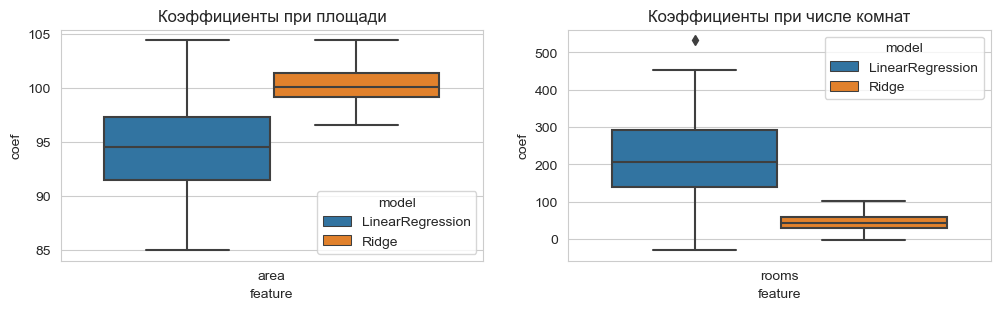

In [15]:
coef_lr = []
coef_ridge = []

for seed in range(42, 142):
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)

    lr = LinearRegression().fit(X_train, y_train)
    ridge = Ridge(alpha=a).fit(X_train, y_train)

    coef_lr.append(lr.coef_)
    coef_ridge.append(ridge.coef_)

df_coef_lr  = pd.DataFrame(data = coef_lr, columns = ['area_lr', 'rooms_lr'])
df_coef_ridge  = pd.DataFrame(data = coef_ridge, columns = ['area_ridge', 'rooms_ridge'])

df_coef = pd.concat([df_coef_lr, df_coef_ridge], axis=1)

df_coef_area_lr = pd.DataFrame(columns = ['model', 'feature', 'coef'])
df_coef_area_lr['coef'] = df_coef_lr['area_lr']
df_coef_area_lr['model'] = 'LinearRegression'
df_coef_area_lr['feature'] = 'area'

df_coef_rooms_lr = pd.DataFrame(columns = ['model', 'feature', 'coef'])
df_coef_rooms_lr['coef'] = df_coef_lr['rooms_lr']
df_coef_rooms_lr['model'] = 'LinearRegression'
df_coef_rooms_lr['feature'] = 'rooms'

df_coef_area_ridge = pd.DataFrame(columns = ['model', 'feature', 'coef'])
df_coef_area_ridge['coef'] = df_coef_ridge['area_ridge']
df_coef_area_ridge['model'] = 'Ridge'
df_coef_area_ridge['feature'] = 'area'

df_coef_rooms_ridge = pd.DataFrame(columns = ['model', 'feature', 'coef'])
df_coef_rooms_ridge['coef'] = df_coef_ridge['rooms_ridge']
df_coef_rooms_ridge['model'] = 'Ridge'
df_coef_rooms_ridge['feature'] = 'rooms'

df_coef = pd.concat([df_coef_area_lr, df_coef_area_ridge, df_coef_rooms_lr, df_coef_rooms_ridge])

fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12, 3))

ax[0].set_title('Коэффициенты при площади')
ax[1].set_title('Коэффициенты при числе комнат')

d_0 = df_coef.loc[df_coef['feature'] == 'area']
sns.boxplot(data=d_0, x='feature', y='coef', hue='model', ax=ax[0])

d_1 = df_coef.loc[df_coef['feature'] == 'rooms']
sns.boxplot(data=d_1, x='feature', y='coef', hue='model', ax=ax[1])

plt.show()

### 1.5. Так все-таки: зачем нам ридж?

#### 1.5.1. Борьба с переобученностью

Здесь берем пример из прошлой лекции. Напомним, в чем он состоял.

#### Контекст
Сеть агентств недвижимости «Дом в Окне» (HouseInWindow) хочет разработать модель автоматической оценки рыночной стоимости квартир. Агенты тратят много времени на ручную оценку, а клиенты жалуются на субъективность. Нужна объективная, воспроизводимая модель, которая предсказывает цену квадратного метра на основе характеристик квартиры.

#### Датасет
- district — район города (категориальный, 3 уникальных значения: Исторический центр, Центр, Окраины) (object).
- wall_type — тип стен (категориальный, 4 значения: кирпич, панель, монолит, дерево) (object).
- street — название улицы (категориальный, ~65 уникальных значений) (object).
#### Таргет
- price_per_sqm — цена квадратного метра в тысячах рублей (float, диапазон 40–280).
#### Бизнес-задача
Предсказывать `price_per_sqm` — чтобы автоматизировать оценку квартир, снизить влияние субъективного фактора и сократить время работы агента.

Мы добавили большое количество столбцов за счет One Hot Encoding при том, что сам датасет имеет небольшое число наблюдений (примерно равное числу получившихся столбцов). В результате — на test'е скор уходит в минус бесконечность:

In [16]:
r2_train_list = []
r2_test_list = []

for a in range(100):

    df = pd.read_csv('data/house_in_window.csv')

    df_loc = df.sample(frac= 0.05)

    df_loc = pd.get_dummies(df_loc, columns=['district', 'wall_type', 'street'])

    X = df_loc.drop(columns='price_per_sqm')
    y = df_loc['price_per_sqm']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)

    model = LinearRegression()
    model.fit(X_train, y_train)

    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    
    r2_train = r2_score(y_train, y_pred_train)
    r2_train_list.append(r2_train)
    
    r2_test = r2_score(y_test, y_pred_test)
    r2_test_list.append(r2_test)
    
print('r2_ave_train =', np.array(r2_train_list).mean())
print('r2_ave_test  =', np.array(r2_test_list).mean())
# print(model.coef_)

r2_ave_train = 0.8715860280315627
r2_ave_test  = -6.35767692369106e+24


Но если вместо LinearRegression использовать Ridge, то все не так плохо:

In [17]:
r2_train_list = []
r2_test_list = []

for a in range(100):

    df = pd.read_csv('data/house_in_window.csv')

    df_loc = df.sample(frac= 0.05)

    df_loc = pd.get_dummies(df_loc, columns=['district', 'wall_type', 'street'])

    X = df_loc.drop(columns='price_per_sqm')
    y = df_loc['price_per_sqm']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)

    model = Ridge()
    model.fit(X_train, y_train)

    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    
    r2_train = r2_score(y_train, y_pred_train)
    r2_train_list.append(r2_train)
    
    r2_test = r2_score(y_test, y_pred_test)
    r2_test_list.append(r2_test)
    
print('r2_ave_train =', np.array(r2_train_list).mean())
print('r2_ave_test  =', np.array(r2_test_list).mean())
# print(model.coef_)

r2_ave_train = 0.90491440222873
r2_ave_test  = 0.8334301091650701


#### 1.5.2. Стабилизация коэффициентов

Здесь нужно что-нибудь про то, как важно в некоторых случаях иметь стабильные коэффициенты модели, потому что это напрямуя связано с интерпретируемостью модели, а это очень важно в некоторых предметных областях. И привести пару примеров.

## § 2 Lasso

Пусть имеется задача линейной регрессии:

$$
Xw=y
$$

Для того, чтобы решить ее методом ортогональных проекций, нужно спроецировать таргет на пространство, порожденное предикторами. Тогда система станет крамеровской и можно будет найти коэффициенты $w$. А предсказание, которое будет давать эта модель — это в точности проекция:

$$
y_{\rm pred} = {\rm Pr}_L(y)\,,\quad\text{где}\quad L = {\rm Span}\{x_1, \dots, x_p\}\,.
$$

Чтобы найти проекцию, ~~достаточно спроецировать таргет на каждый из предикторов и вязть сумму получившихся проекций~~. Это не так. Чтобы это было так, нужно чтобы предикторы были взаимно ортогональны. Тогда — да, проекция на подпространство — это сумма проекций на базисные векторы. Но они не ортогональны.

Можно было бы поступить по алгебраической классике: применить к набору предикторов процесс ортогонализации Грама-Шмидта, и взять проекцию на получившийся ортогональный базис. Теоретически — да. Но при этом вместо изначальных предикторов, которые интрепретирются в предметной области, у нас будут дикие линейные комбинации, про которые уже никто не знает, что они означают. А коэффициенты регрессии будут считаться уже относительно этих диких линейных комбинаций. После чего — опять-таки не понятно, какой из признаков оказывает какое влияние на таргет.

Поэтому вместо алгебраического решения здесь применяется итерационный метод, который называется методом покоординатного спуска. 

### 2.1. Покоординатный спуск

Его суть, если выражаться совсем на пальцах, предельно проста: ну и что, что базисные векторы не ортогональны? А мы все равно на них спроецируем таргет!

Только будем делать это последовательно. Постепенно приближаясь к решению регрессионной задачи. Итак, нам нужно обучить модель линейной регрессии. Обучить регрессор — значит, найти коэффициенты $w_1, \dots, w_p$, и мы будем искать их на каждом шаге итерации по формуле:

$$
w_j^{(k+1)} = \frac{\langle x_j, y - y_{\rm pred}^{(k)}\rangle}{\langle x_j, x_j\rangle} + w_j^{(k)}\,.
$$

А начинать этот процесс мы будем с нулевых коэффициентов: $w^{(0)}=0$. 

Обратите внимание, что при этом происходит с нашей формулой на первом шаге итерации:

$$
w_j^{(1)} = \frac{\langle x_j, y\rangle}{\langle x_j, x_j\rangle}\,.
$$

Это не что иное как коэффициент, на который нужно умножить вектор $x_j$, чтобы получиласть проекция ${\rm Pr}_{x_j}(y)$. И так с каждым предиктором. То есть, на этом шаге мы спроецировали $y$ и на базисные векторы $x_1, \dots, x_n$ и сложили проекции. 

Алгебраисты смотрят на нас с недоумением, а потом начинают ~~молча бить~~ смеяться. 

Но мы уже и сами понимаем, что мы какую-то глупость сморозили. Поэтому мы снова применяем эту формулу, но уже не к таргету $y$, а к вектору невязки $y - y_{\rm pred}^{(1)}$, используя найденные на предыдущем шаге коэффициенты $w_j^{(1)}$:

$$
w_j^{(2)} = \frac{\langle x_j, y - y_{\rm pred}^{(1)}\rangle}{\langle x_j, x_j\rangle} + w_j^{(1)}\,.
$$

И так далее. Теоретически, этот процесс должен сойтись, причем к коэффициентам классической линейной регрессии. Давайте рассмотрим какой-нибудь пример.

#### Игрушечный пример

Пусть нужно решить регрессионную задачу:

$$
\left(
\begin{array}{rr}
x_{11}&x_{12}\\
x_{21}&x_{22}\\
x_{31}&x_{32}
\end{array}
\right)
\cdot
\left(
\begin{array}{r}
w_1\\
w_2
\end{array}
\right)
=\left(
\begin{array}{r}
y_1\\
y_2\\
y_3
\end{array}
\right)
$$

Например, такую:

In [18]:
X = np.array([
    [3, 1],
    [1, 2],
    [0, 0]
])

y = np.array([
    2,
    2,
    1
])

Задаем стартовое значение коэффициентов:

In [20]:
w = np.array([0., 0.])

Задаем уровень точности:

In [21]:
tolerance = 1e-6

Если следующее решение отличается от предыдущего на величину, меньшую `tolerance`, мы будем сичтать, что процесс сошелся, и дальнейшие уточннения коэффициентов уже не требуются.

Решаем задачу, используя, на всякий случай много итераций (а именно — 1000):

In [22]:
w_df = pd.DataFrame(columns = ['w_1', 'w_2'])
w_df['w_1'] = [w[0]]
w_df['w_2'] = [w[1]]

w_pairs_df = pd.DataFrame(columns = ['w_1', 'w_2'])
w_pairs_df['w_1'] = [w[0]]
w_pairs_df['w_2'] = [w[1]]

w_new = w.copy()

for k in range(1000):

    w_new[0] = (X[:,0]@(y - X@w))/(X[:,0]@X[:,0]) + w[0]
    
    arr_df = pd.DataFrame(w_new.reshape(1, -1), columns=w_df.columns)
    w_df = pd.concat([w_df, arr_df], ignore_index=True)
    
    w_new[1] = (X[:,1]@(y - X@w))/(X[:,1]@X[:,1]) + w[1]
    
    arr_df = pd.DataFrame(w_new.reshape(1, -1), columns=w_df.columns)
    w_df = pd.concat([w_df, arr_df], ignore_index=True)

    w = w_new.copy()
    
    w_pairs_df = pd.concat([w_pairs_df, arr_df], ignore_index=True)
    
    if ((w_pairs_df.iloc[len(w_pairs_df) - 1] - w_pairs_df.iloc[len(w_pairs_df) - 2])**2).sum() < tolerance:
        print('Потребовалось итераций:', k)
        print('Коэффициенты:')
        print('w_1 =', w_df['w_1'][len(w_df) -1])
        print('w_2 =', w_df['w_2'][len(w_df) -1])
        break

Потребовалось итераций: 21
Коэффициенты:
w_1 = 0.39980468750000014
w_2 = 0.7996093750000001


На самом деле, процесс сошелся довольно быстро. Все итерации не потребовались. А теперь посмотрим, как в ходе этого процесса вели себя коэффициенты $w_1$ и $w_2$:

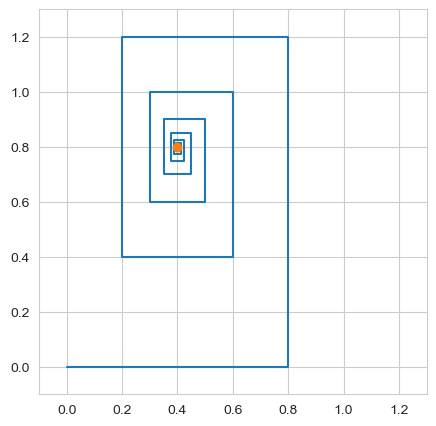

In [23]:
plt.figure(figsize = (5, 5))

m = min(w_df['w_1'].min(), w_df['w_2'].min())
M = max(w_df['w_1'].max(), w_df['w_2'].max())

b = 0.1

plt.xlim([m - b, M + b])
plt.ylim([m - b, M + b])
plt.grid(True)

plt.plot(w_df['w_1'], w_df['w_2'])
plt.plot(w_df.iloc[len(w_df) -1]['w_1'], w_df.iloc[len(w_df) -1]['w_2'], 'o')

plt.show()

Теперь поятно, почему соответствующией метолод регуляризации называется лассо? Очень похожий образ.

Ну и в завершение этого игрушечного примера — как ведут себя предсказания модели на каждом шаге итерации. По условию, имеем два вектора и точку ортогональной проекции таргета (сам таргет — трехмерный, он выступает вверх над плоскостью на единицу).

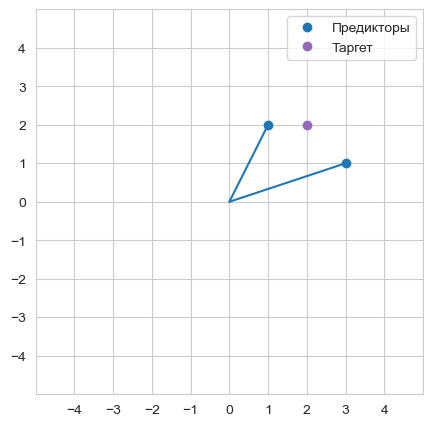

In [24]:
plt.figure(figsize = (5, 5))
plt.xlim([-5, 5])
plt.ylim([-5, 5])
plt.xticks(range(-4, 5))
plt.yticks(range(-4, 5))
plt.grid(True)

plt.plot([0, X[0][0]], [0, X[1][0]], '-', color='C0')
plt.plot(X[0][0], X[1][0], 'o', color='C0', label = 'Предикторы' )

plt.plot([0, X[0][1]], [0, X[1][1]], '-', color='C0')
plt.plot(X[0][1], X[1][1], 'o', color='C0')

plt.plot(y[0], y[1], 'o', color='C4', label = 'Таргет')

plt.legend()

plt.show()

По сути, фиолетовая точка — это и есть предсказание модели линейной регрессии. Но мы будем приближаться к нему итеративно:

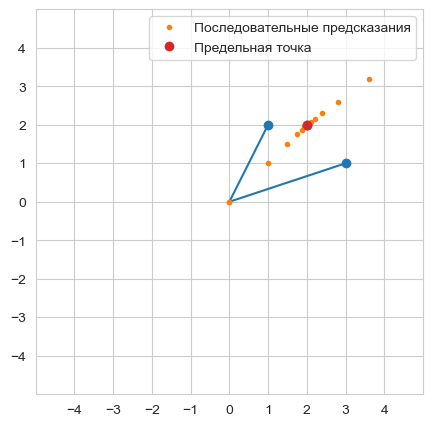

In [25]:
plt.figure(figsize = (5, 5))
plt.xlim([-5, 5])
plt.ylim([-5, 5])
plt.xticks(range(-4, 5))
plt.yticks(range(-4, 5))
plt.grid(True)

plt.plot([0, X[0][0]], [0, X[1][0]], '-', color='C0')
plt.plot(X[0][0], X[1][0], 'o', color='C0')

plt.plot([0, X[0][1]], [0, X[1][1]], '-', color='C0')
plt.plot(X[0][1], X[1][1], 'o', color='C0')

plt.plot(y[0], y[1], 'o', color='C0')

for i in range(1):
    
    y_pred = X[:-1][:,0] * w_pairs_df['w_1'][i] + X[:-1][:,1] * w_pairs_df['w_2'][i]
    plt.plot(y_pred[0], y_pred[1], '.', color = 'C1', label = 'Последовательные предсказания')

for i in range(len(w_pairs_df)):
    
    y_pred = X[:-1][:,0] * w_pairs_df['w_1'][i] + X[:-1][:,1] * w_pairs_df['w_2'][i]
    plt.plot(y_pred[0], y_pred[1], '.', color = 'C1')

plt.plot(y_pred[0], y_pred[1], 'o', color = 'C3', label = 'Предельная точка')
plt.legend()
plt.show()

Как видим, предельная точка совпала с проекцией таргета, то есть — с предсказанием классической линейной регрессии.

#### Функция покоординатного спуска

Чтобы не таскать за собой этот огромный код, упакуем его в функцию. Она принимает на вход матрицу `X`, вектор `y`, стратовые значения коэфициентов `w`, толерантность `tolerance` и максимальное число итераций `n_iter`, а возвращает число исполненных итерация до выхода из цикла, финишные значения коэффициентов и три картинки.

In [26]:
def descent_with_pictures(X, y, w, tolerance, n_iter):
    w_df = pd.DataFrame(columns = ['w_1', 'w_2'])
    w_df['w_1'] = [w[0]]
    w_df['w_2'] = [w[1]]

    w_pairs_df = pd.DataFrame(columns = ['w_1', 'w_2'])
    w_pairs_df['w_1'] = [w[0]]
    w_pairs_df['w_2'] = [w[1]]

    w_new = w.copy()

    for k in range(n_iter):

        w_new[0] = (X[:,0]@(y - X@w))/(X[:,0]@X[:,0]) + w[0]

        arr_df = pd.DataFrame(w_new.reshape(1, -1), columns=w_df.columns)
        w_df = pd.concat([w_df, arr_df], ignore_index=True)

        w_new[1] = (X[:,1]@(y - X@w))/(X[:,1]@X[:,1]) + w[1]

        arr_df = pd.DataFrame(w_new.reshape(1, -1), columns=w_df.columns)
        w_df = pd.concat([w_df, arr_df], ignore_index=True)

        w = w_new.copy()

        w_pairs_df = pd.concat([w_pairs_df, arr_df], ignore_index=True)

        if ((w_pairs_df.iloc[len(w_pairs_df) - 1] - w_pairs_df.iloc[len(w_pairs_df) - 2])**2).sum() < tolerance:
            print('Потребовалось итераций:', k)
            print('Коэффициенты:')
            print('w_1 =', w_df['w_1'][len(w_df) -1])
            print('w_2 =', w_df['w_2'][len(w_df) -1])
            break
            
    if k == n_iter - 1:
        print('Процесс не сошелся')

    plt.figure(figsize = (5, 5))

    m = min(w_df['w_1'].min(), w_df['w_2'].min())
    M = max(w_df['w_1'].max(), w_df['w_2'].max())

    b = 0.1

    plt.xlim([m - b, M + b])
    plt.ylim([m - b, M + b])
    plt.grid(True)

    plt.plot(w_df['w_1'], w_df['w_2'])
    plt.plot(w_df.iloc[len(w_df) -1]['w_1'], w_df.iloc[len(w_df) -1]['w_2'], 'o')

    plt.show()

    plt.figure(figsize = (5, 5))
    plt.xlim([-5, 5])
    plt.ylim([-5, 5])
    plt.xticks(range(-4, 5))
    plt.yticks(range(-4, 5))
    plt.grid(True)

    plt.plot([0, X[0][0]], [0, X[1][0]], '-', color='C0')
    plt.plot(X[0][0], X[1][0], 'o', color='C0', label = 'Предикторы' )

    plt.plot([0, X[0][1]], [0, X[1][1]], '-', color='C0')
    plt.plot(X[0][1], X[1][1], 'o', color='C0')

    plt.plot(y[0], y[1], 'o', color='C4', label = 'Таргет')

    plt.legend()

    plt.show()

    plt.figure(figsize = (5, 5))
    plt.xlim([-5, 5])
    plt.ylim([-5, 5])
    plt.xticks(range(-4, 5))
    plt.yticks(range(-4, 5))
    plt.grid(True)

    plt.plot([0, X[0][0]], [0, X[1][0]], '-', color='C0')
    plt.plot(X[0][0], X[1][0], 'o', color='C0')

    plt.plot([0, X[0][1]], [0, X[1][1]], '-', color='C0')
    plt.plot(X[0][1], X[1][1], 'o', color='C0')

    plt.plot(y[0], y[1], 'o', color='C0')

    for i in range(1):

        y_pred = X[:-1][:,0] * w_pairs_df['w_1'][i] + X[:-1][:,1] * w_pairs_df['w_2'][i]
        plt.plot(y_pred[0], y_pred[1], '.', color = 'C1', label = 'Последовательные предсказания')

    for i in range(len(w_pairs_df)):

        y_pred = X[:-1][:,0] * w_pairs_df['w_1'][i] + X[:-1][:,1] * w_pairs_df['w_2'][i]
        plt.plot(y_pred[0], y_pred[1], '.', color = 'C1')

    plt.plot(y_pred[0], y_pred[1], 'o', color = 'C3', label = 'Предельная точка')
    plt.legend()
    plt.show()
    
print('Функция активирована.')

Функция активирована.


#### Еще один игрушечный пример

Потребовалось итераций: 18
Коэффициенты:
w_1 = 0.9990234375
w_2 = -0.998046875


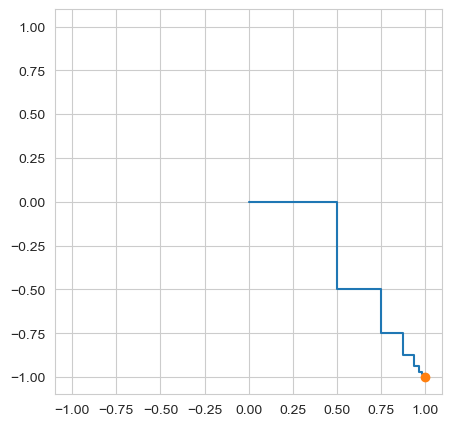

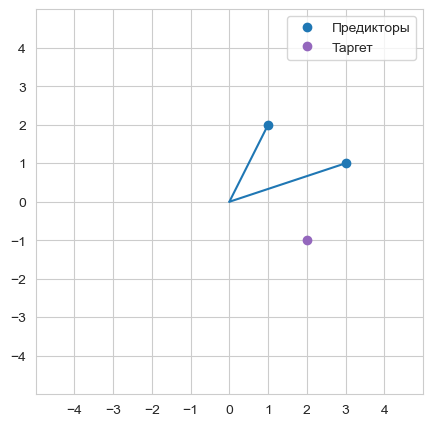

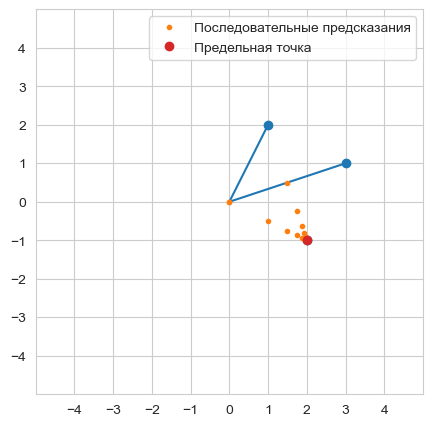

In [27]:
X = np.array([
    [3, 1],
    [1, 2],
    [0, 0]
])

y = np.array([
    2,
    -1,
    1
])

w = np.array([0., 0.])

tolerance = 1e-6

n_iter = 1000

descent_with_pictures(X, y, w, tolerance, n_iter)

Здесь траекторя движения коэффициентов меньше похожа на лассо. Но процесс сошелся, за небольшое число итераций мы попали в предельную точку.

#### И еще один. Про мультколлинеарность

Процесс не сошелся


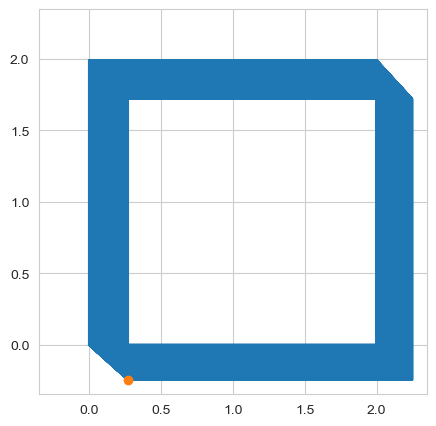

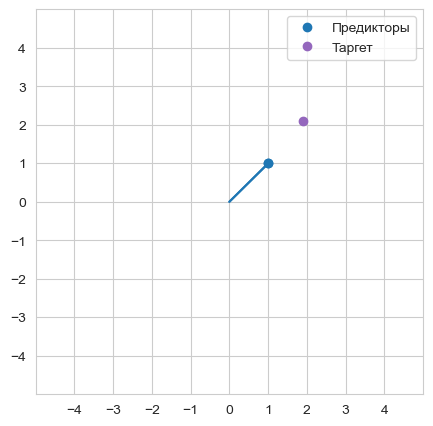

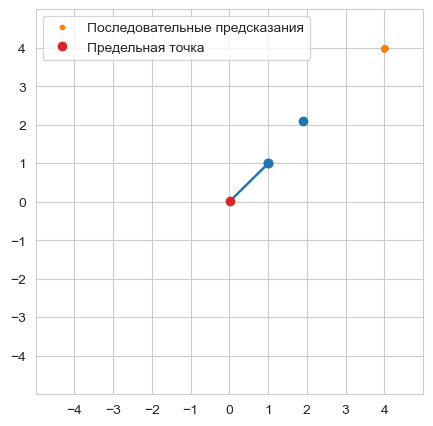

In [28]:
X = np.array([
    [1, 1.01],
    [1, 1],
    [0, 0]
])

y = np.array([
    1.9,
    2.1,
    1
])

w = np.array([0., 0.])

tolerance = 1e-6

n_iter = 1000

descent_with_pictures(X, y, w, tolerance, n_iter)

А вот здесь — облом. Проявила себя все та же мультиколлинеарность, с которой мы так усиленно боролись при помощи ридж-регуляризации.

### 2.2. Мягкий порог регуляризации

Ну, во-первых, порог бывает не только мягкий, но и жесткий. Его идея заключается в том, что если коэффициент слишком маленький, то давайте считать его нулем. А если не слишком — то пусть останется как есть. Величина «слишком маленький» — это просто некоторое число $\gamma$, которое называется порогом регуляризации. Математически функция жесткого порога описывается так:

$$
{\rm hard }(z)
=
\left\{
\begin{array}{rl}
z, & \text{если } |z|\geq \gamma\,;\\
0, & \text{если } |z|< \gamma\,.
\end{array}
\right.
$$

А мягкий порог ведет себя иначе. Он говорит: если коэффициент слишком маленький, то давайте считать его нулем. А если не слишком — то мы все равно уменьшим его на величину порога. Вот его формула:

$$
{\rm soft }(z)
=
\left\{
\begin{array}{rl}
z - \gamma, & \text{если } z\geq \gamma\,;\\
0, & \text{если } |z|< \gamma\,;\\
z + \gamma, & \text{если } z\leq -\gamma\,;\\
\end{array}
\right.
$$

Опишем эти функции на языке Python:

In [29]:
def hard(z, gamma):
    if abs(z) >= gamma:
        return z
    else:
        return 0
    
def soft(z, gamma):
    if z >= gamma:
        return z - gamma
    elif z <= -gamma:
        return z + gamma
    else:
        return 0
    
print('Функции активированы')

Функции активированы


И полюбуемся на картинки:

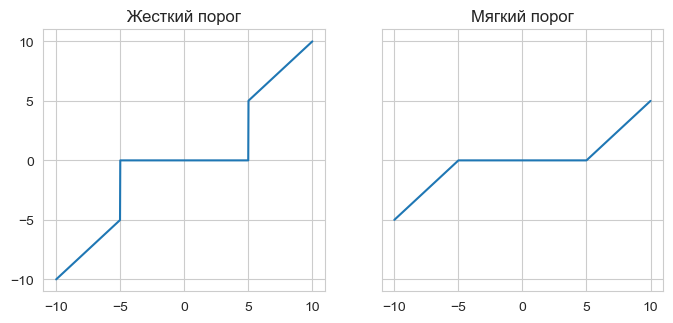

In [31]:
z = np.linspace(-10, 10, 1000)
gamma = 5

hard_list = []
soft_list = []

for x in z:
    hard_list.append(hard(x, gamma))
    soft_list.append(soft(x, gamma))

fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (8, 3.4), sharey=True)

ax[0].set_title('Жесткий порог')
ax[0].set_xticks([-10, -5, 0, 5, 10])
ax[0].set_yticks([-10, -5, 0, 5, 10])
ax[0].grid(True)

ax[1].set_title('Мягкий порог')
ax[1].grid(True)

ax[0].plot(z, hard_list)
ax[1].plot(z, soft_list)


plt.show()

Как видим, жесткий порог — это разрывная функция, а мягкий — непрерывная. Это уже хорошо, потому что это обеспечивает устойчивость коэффициентов про переходе через порог. 

Если порог жесткий, то коэффициент 4.999 станет 0, а 5.001 — останется 5.001: разница между регуляризованными коэффициентами будет большой. А если порог мягкий, то 4.999 станет 0, а 5.001 станет 0.001: разница между регуляризованными коэффициентами будет маленькой.

#### Еще раз пример с мультиколлинеарностью

Попробуем решить неудавшийся выше пример, используя мягкий порог регуляризации. 

In [32]:
X = np.array([
    [1, 1.01],
    [1, 1],
    [0, 0]
])

y = np.array([
    1.9,
    2.1,
    1
])

w = np.array([0., 0.])

tolerance = 1e-6

n_iter = 1000

lam = 0.5

w_df = pd.DataFrame(columns = ['w_1', 'w_2'])
w_df['w_1'] = [w[0]]
w_df['w_2'] = [w[1]]

w_pairs_df = pd.DataFrame(columns = ['w_1', 'w_2'])
w_pairs_df['w_1'] = [w[0]]
w_pairs_df['w_2'] = [w[1]]

w_new = w.copy()

for k in range(n_iter):
    
    z = (X[:,0]@(y - X@w))/(X[:,0]@X[:,0]) + w[0]
    w_new[0] = soft(z, lam)
    
    arr_df = pd.DataFrame(w_new.reshape(1, -1), columns=w_df.columns)
    w_df = pd.concat([w_df, arr_df], ignore_index=True)
    
    z = (X[:,1]@(y - X@w))/(X[:,1]@X[:,1]) + w[1]
    w_new[1] = soft(z, lam)
    
    arr_df = pd.DataFrame(w_new.reshape(1, -1), columns=w_df.columns)
    w_df = pd.concat([w_df, arr_df], ignore_index=True)

    w = w_new.copy()
    
    w_pairs_df = pd.concat([w_pairs_df, arr_df], ignore_index=True)
    
    if ((w_pairs_df.iloc[len(w_pairs_df) - 1] - w_pairs_df.iloc[len(w_pairs_df) - 2])**2).sum() < tolerance:
        print('Потребовалось итераций:', k)
        print('Коэффициенты:')
        print('w_1 =', w_df['w_1'][len(w_df) -1])
        print('w_2 =', w_df['w_2'][len(w_df) -1])
        break
        
if k == n_iter - 1:
    print('Процесс не сошелся')

Потребовалось итераций: 990
Коэффициенты:
w_1 = 1.5
w_2 = 0.0


Что мы здесь сделали. Мы ввели параметр регуляризации — величину порога — `lam = 0.5`, и то, что мы раньше считали значениями коэффициентов, теперь пропускаем через мягкий порог: если нйденное значение меньше 0.5, то результат — 0, а если больше, то результат — уменьшается на 0.5.

При этом, мы разумеется потеряли точность. Понятно, что коэффициент там должен быть 2, а не 1.5. Зато процесс сошелся.

#### Функция покоординатного спуска с мягким порогом

Опять-таки, чтобы не таскать за собой громоздкий код, опишем алгоритм в виде функции:

In [33]:
def descent_soft(X, y, w, tolerance, n_iter, lam):

    w_df = pd.DataFrame(columns = ['w_1', 'w_2'])
    w_df['w_1'] = [w[0]]
    w_df['w_2'] = [w[1]]

    w_pairs_df = pd.DataFrame(columns = ['w_1', 'w_2'])
    w_pairs_df['w_1'] = [w[0]]
    w_pairs_df['w_2'] = [w[1]]

    w_new = w.copy()

    for k in range(n_iter):

        z = (X[:,0]@(y - X@w))/(X[:,0]@X[:,0]) + w[0]
        w_new[0] = soft(z, lam)

        arr_df = pd.DataFrame(w_new.reshape(1, -1), columns=w_df.columns)
        w_df = pd.concat([w_df, arr_df], ignore_index=True)

        z = (X[:,1]@(y - X@w))/(X[:,1]@X[:,1]) + w[1]
        w_new[1] = soft(z, lam)

        arr_df = pd.DataFrame(w_new.reshape(1, -1), columns=w_df.columns)
        w_df = pd.concat([w_df, arr_df], ignore_index=True)

        w = w_new.copy()

        w_pairs_df = pd.concat([w_pairs_df, arr_df], ignore_index=True)

        if ((w_pairs_df.iloc[len(w_pairs_df) - 1] - w_pairs_df.iloc[len(w_pairs_df) - 2])**2).sum() < tolerance:
            print('Потребовалось итераций:', k)
            print('Коэффициенты:')
            print('w_1 =', w_df['w_1'][len(w_df) -1])
            print('w_2 =', w_df['w_2'][len(w_df) -1])
            break

    if k == n_iter - 1:
        print('Процесс не сошелся')
        
def descent_soft_with_pictures(X, y, w, tolerance, n_iter, lam):

    w_df = pd.DataFrame(columns = ['w_1', 'w_2'])
    w_df['w_1'] = [w[0]]
    w_df['w_2'] = [w[1]]

    w_pairs_df = pd.DataFrame(columns = ['w_1', 'w_2'])
    w_pairs_df['w_1'] = [w[0]]
    w_pairs_df['w_2'] = [w[1]]

    w_new = w.copy()

    for k in range(n_iter):

        z = (X[:,0]@(y - X@w))/(X[:,0]@X[:,0]) + w[0]
        w_new[0] = soft(z, lam)

        arr_df = pd.DataFrame(w_new.reshape(1, -1), columns=w_df.columns)
        w_df = pd.concat([w_df, arr_df], ignore_index=True)

        z = (X[:,1]@(y - X@w))/(X[:,1]@X[:,1]) + w[1]
        w_new[1] = soft(z, lam)

        arr_df = pd.DataFrame(w_new.reshape(1, -1), columns=w_df.columns)
        w_df = pd.concat([w_df, arr_df], ignore_index=True)

        w = w_new.copy()

        w_pairs_df = pd.concat([w_pairs_df, arr_df], ignore_index=True)

        if ((w_pairs_df.iloc[len(w_pairs_df) - 1] - w_pairs_df.iloc[len(w_pairs_df) - 2])**2).sum() < tolerance:
            print('Потребовалось итераций:', k)
            print('Коэффициенты:')
            print('w_1 =', w_df['w_1'][len(w_df) -1])
            print('w_2 =', w_df['w_2'][len(w_df) -1])
            break

    if k == n_iter - 1:
        print('Процесс не сошелся')
        
    plt.figure(figsize = (5, 5))

    m = min(w_df['w_1'].min(), w_df['w_2'].min())
    M = max(w_df['w_1'].max(), w_df['w_2'].max())

    b = 0.1

    plt.xlim([m - b, M + b])
    plt.ylim([m - b, M + b])
    plt.grid(True)

    plt.plot(w_df['w_1'], w_df['w_2'])
    plt.plot(w_df.iloc[len(w_df) -1]['w_1'], w_df.iloc[len(w_df) -1]['w_2'], 'o')

    plt.show()

    plt.figure(figsize = (5, 5))
    plt.xlim([-5, 5])
    plt.ylim([-5, 5])
    plt.xticks(range(-4, 5))
    plt.yticks(range(-4, 5))
    plt.grid(True)

    plt.plot([0, X[0][0]], [0, X[1][0]], '-', color='C0')
    plt.plot(X[0][0], X[1][0], 'o', color='C0', label = 'Предикторы' )

    plt.plot([0, X[0][1]], [0, X[1][1]], '-', color='C0')
    plt.plot(X[0][1], X[1][1], 'o', color='C0')

    plt.plot(y[0], y[1], 'o', color='C4', label = 'Таргет')

    plt.legend()

    plt.show()

    plt.figure(figsize = (5, 5))
    plt.xlim([-5, 5])
    plt.ylim([-5, 5])
    plt.xticks(range(-4, 5))
    plt.yticks(range(-4, 5))
    plt.grid(True)

    plt.plot([0, X[0][0]], [0, X[1][0]], '-', color='C0')
    plt.plot(X[0][0], X[1][0], 'o', color='C0')

    plt.plot([0, X[0][1]], [0, X[1][1]], '-', color='C0')
    plt.plot(X[0][1], X[1][1], 'o', color='C0')

    plt.plot(y[0], y[1], 'o', color='C0')

    for i in range(1):

        y_pred = X[:-1][:,0] * w_pairs_df['w_1'][i] + X[:-1][:,1] * w_pairs_df['w_2'][i]
        plt.plot(y_pred[0], y_pred[1], '.', color = 'C1', label = 'Последовательные предсказания')

    for i in range(len(w_pairs_df)):

        y_pred = X[:-1][:,0] * w_pairs_df['w_1'][i] + X[:-1][:,1] * w_pairs_df['w_2'][i]
        plt.plot(y_pred[0], y_pred[1], '.', color = 'C1')

    plt.plot(y_pred[0], y_pred[1], 'o', color = 'C3', label = 'Предельная точка')
    plt.legend()
    plt.show()
    
print('Функция активирована')

Функция активирована


#### Вариация порога

Давайте посмотрим, что происходит с результатами, когда мы начинаем варьировать величину порога. 

Возьмем наш самый первый пример.

Если `lam=0`, то мы получаем обычную линейную регрессию: предельная точка процесса попадает именно в проекцию таргета.

Но если `lam` принимает нетривиальные значения, что предельная точка тем сильнее отклоняется, чем больше величина порога.

Потребовалось итераций: 5
Коэффициенты:
w_1 = 0.0
w_2 = 0.7


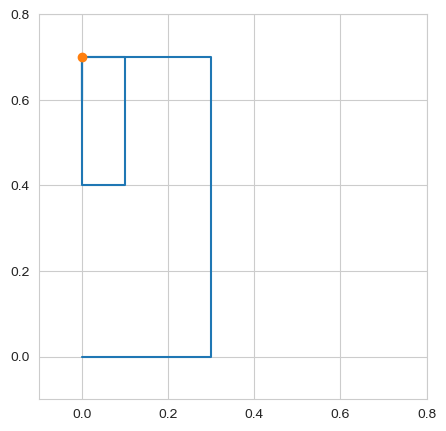

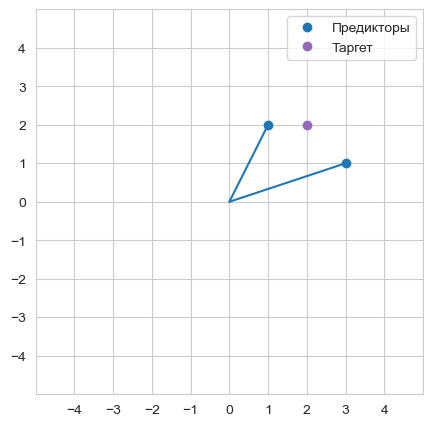

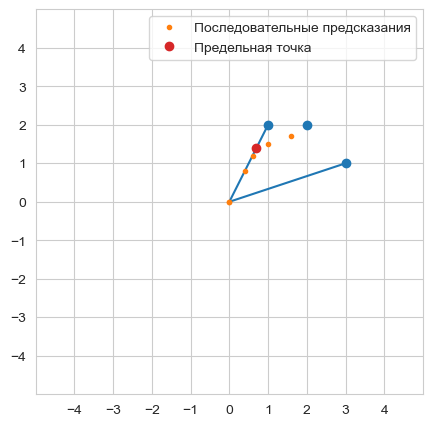

In [36]:
X = np.array([
    [3, 1],
    [1, 2],
    [0, 0]
])

y = np.array([
    2,
    2,
    1
])

w = np.array([0., 0.])

tolerance = 1e-6

n_iter = 1000

# Попробуйте разные значения lam и посмотрите на картинки

descent_soft_with_pictures(X, y, w, tolerance, n_iter, lam=0.5)

#### И еще раз пример с мультиколлинеарностью

Потребовалось итераций: 437
Коэффициенты:
w_1 = 1.1
w_2 = 0.0


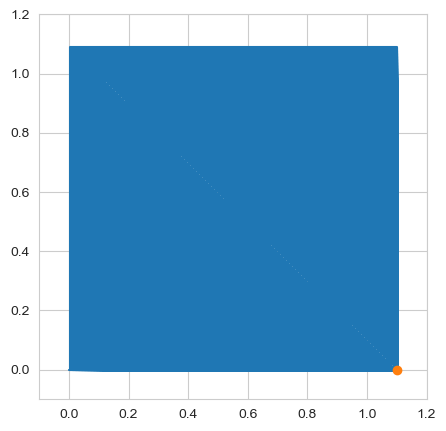

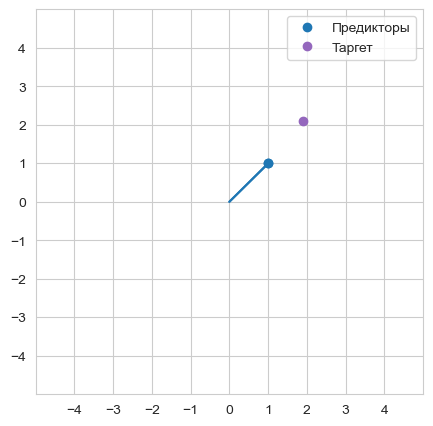

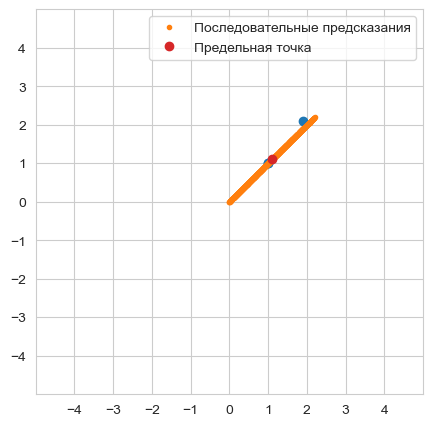

In [42]:
X = np.array([
    [1, 1.01],
    [1, 1],
    [0, 0]
])

y = np.array([
    1.9,
    2.1,
    1
])

w = np.array([0., 0.])

tolerance = 1e-6

n_iter = 1000

# Попробуйте разные значения lam и посмотрите на картинки

descent_soft_with_pictures(X, y, w, tolerance, n_iter, lam=0.9)

### 2.3. Менее игрушечный пример

Мы этот пример рассматривали выше, когда сравнивали LinearRegression и Ridge. А теперь подключим еще и Lasso.

In [43]:
df = pd.read_csv('data/area_rooms.csv')

X = df.drop(columns = ['price'])
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)

y_train_pred_lr = lr.predict(X_train)
y_test_pred_lr = lr.predict(X_test)

print('Линейная регрессия')
print('')
print('Коэффициенты: area =', round(lr.coef_[0], 2), ', rooms =', round(lr.coef_[1], 2))
print('Свободный член:', round(lr.intercept_, 2))
print('R² на train:', round(r2_score(y_train, y_train_pred_lr), 4))
print('R² на test:',  round(r2_score(y_test, y_test_pred_lr), 4))

ridge = Ridge(alpha=50)
ridge.fit(X_train, y_train)

y_train_pred_ridge = ridge.predict(X_train)
y_test_pred_ridge = ridge.predict(X_test)

print('')
print('Ридж')
print('')

print('Коэффициенты: area =', round(ridge.coef_[0], 2), ', rooms =', round(ridge.coef_[1], 2))
print('Свободный член:', round(ridge.intercept_, 2))
print('R² на train:', round(r2_score(y_train, y_train_pred_ridge), 4))
print('R² на test:',  round(r2_score(y_test, y_test_pred_ridge), 4))

lasso = Lasso(alpha=50)
lasso.fit(X_train, y_train)

y_train_pred_lasso = lasso.predict(X_train)
y_test_pred_lasso = lasso.predict(X_test)

print('')
print('Лассо')
print('')

print('Коэффициенты: area =', round(lasso.coef_[0], 2), ', rooms =', round(lasso.coef_[1], 2))
print('Свободный член:', round(lasso.intercept_, 2))
print('R² на train:', round(r2_score(y_train, y_train_pred_lasso), 4))
print('R² на test:',  round(r2_score(y_test, y_test_pred_lasso), 4))

Линейная регрессия

Коэффициенты: area = 100.05 , rooms = 66.95
Свободный член: -145.38
R² на train: 0.9628
R² на test: 0.9527

Ридж

Коэффициенты: area = 101.94 , rooms = 10.08
Свободный член: -147.83
R² на train: 0.9627
R² на test: 0.9522

Лассо

Коэффициенты: area = 102.33 , rooms = 0.0
Свободный член: -152.4
R² на train: 0.9627
R² на test: 0.952


Видите? Линейная регрессия считает, что предиктор `room` важный. Ридж — что он не такой уж и важный. А Лассо считает, что он вообще не нужен. При этом скор на test'е — не падает! Вот так. 

Ну и можно посмотреть на стабильноость коэффициентов для всех трех моделей:

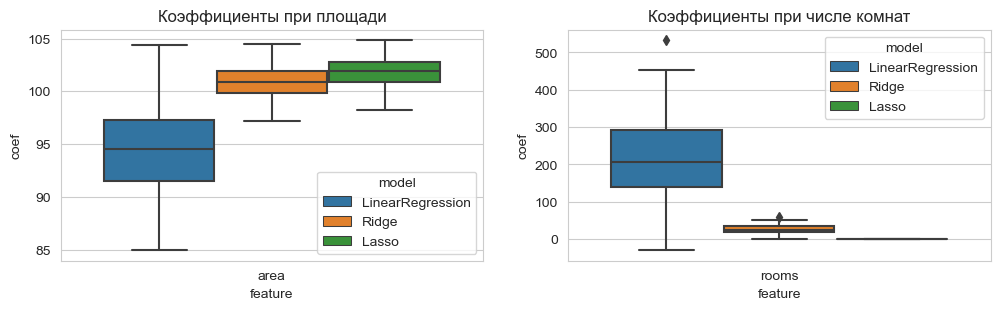

In [44]:
coef_lr = []
coef_ridge = []
coef_lasso = []

for seed in range(42, 142):
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)

    lr = LinearRegression().fit(X_train, y_train)
    ridge = Ridge(alpha=50).fit(X_train, y_train)
    lasso = Lasso(alpha=50).fit(X_train, y_train)

    coef_lr.append(lr.coef_)
    coef_ridge.append(ridge.coef_)
    coef_lasso.append(lasso.coef_)

df_coef_lr  = pd.DataFrame(data = coef_lr, columns = ['area_lr', 'rooms_lr'])
df_coef_ridge  = pd.DataFrame(data = coef_ridge, columns = ['area_ridge', 'rooms_ridge'])
df_coef_lasso  = pd.DataFrame(data = coef_lasso, columns = ['area_lasso', 'rooms_lasso'])

df_coef = pd.concat([df_coef_lr, df_coef_ridge, df_coef_lasso], axis=1)

df_coef_area_lr = pd.DataFrame(columns = ['model', 'feature', 'coef'])
df_coef_area_lr['coef'] = df_coef_lr['area_lr']
df_coef_area_lr['model'] = 'LinearRegression'
df_coef_area_lr['feature'] = 'area'

df_coef_rooms_lr = pd.DataFrame(columns = ['model', 'feature', 'coef'])
df_coef_rooms_lr['coef'] = df_coef_lr['rooms_lr']
df_coef_rooms_lr['model'] = 'LinearRegression'
df_coef_rooms_lr['feature'] = 'rooms'

df_coef_area_ridge = pd.DataFrame(columns = ['model', 'feature', 'coef'])
df_coef_area_ridge['coef'] = df_coef_ridge['area_ridge']
df_coef_area_ridge['model'] = 'Ridge'
df_coef_area_ridge['feature'] = 'area'

df_coef_rooms_ridge = pd.DataFrame(columns = ['model', 'feature', 'coef'])
df_coef_rooms_ridge['coef'] = df_coef_ridge['rooms_ridge']
df_coef_rooms_ridge['model'] = 'Ridge'
df_coef_rooms_ridge['feature'] = 'rooms'

df_coef_area_lasso = pd.DataFrame(columns = ['model', 'feature', 'coef'])
df_coef_area_lasso['coef'] = df_coef_lasso['area_lasso']
df_coef_area_lasso['model'] = 'Lasso'
df_coef_area_lasso['feature'] = 'area'

df_coef_rooms_lasso = pd.DataFrame(columns = ['model', 'feature', 'coef'])
df_coef_rooms_lasso['coef'] = df_coef_lasso['rooms_lasso']
df_coef_rooms_lasso['model'] = 'Lasso'
df_coef_rooms_lasso['feature'] = 'rooms'

df_coef = pd.concat([df_coef_area_lr, df_coef_area_ridge, df_coef_area_lasso, df_coef_rooms_lr, df_coef_rooms_ridge, df_coef_rooms_lasso])

fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12, 3))

ax[0].set_title('Коэффициенты при площади')
ax[1].set_title('Коэффициенты при числе комнат')

d_0 = df_coef.loc[df_coef['feature'] == 'area']
sns.boxplot(data=d_0, x='feature', y='coef', hue='model', ax=ax[0])

d_1 = df_coef.loc[df_coef['feature'] == 'rooms']
sns.boxplot(data=d_1, x='feature', y='coef', hue='model', ax=ax[1])

plt.show()

### 2.4. Когда нужен ридж, и когда нужен лассо?

Здесь про то, что ридж нужен, когда для нас, в силу каких-то обстоятельств, важны абсолютно все предикторы и мы не можем себе позволить потерять информацию хотя бы об одном из них. А лассо — когда мы можем сбе позволить выкинуть сколько угодно предикторов (а, может быть, даже и стремимся к этому).

## § 3. Исследование данных при помощи Ridge и Lasso

### 3.1. Исследование при помощи Ridge

#### Контекст

Больница собирает данные пациентов, чтобы построить модель вероятности инфаркта в ближайшие 5 лет. Врачам — людям с консервативным мышлением и клятвой Гиппократа — нужно не просто предсказание, а понимание: как каждый фактор влияет. Они должны объяснить пациенту: «Вот, смотрите, у вас повышен холестерин, поэтому риск растёт. Давайте снижать».

Предикторы

- Age — возраст (int),

- Total_Cholesterol — Холестерин общий (float),

- LDL — холестерин (float),

- BMI — индекс массы тела (float),

- Systolic_BP — систолическое давление (float),

- Smoker — курение (да/нет) (int)/

#### Таргет

- Вероятность инфаркта в ближайшие 5 лет (float).

In [45]:
df=pd.read_csv('data/heart_attack.csv')
df

,Age,Total_Cholesterol,LDL,BMI,Systolic_BP,Smoker,Heart_Attack_Risk
0,49,177.917523,151.201768,25.515949,119.056527,0,0.650889
1,78,162.060970,137.750163,39.553916,136.654845,1,0.981769
2,67,190.903806,162.238140,26.808856,125.230581,0,0.882155
3,60,192.178177,163.366652,26.083351,120.359203,0,0.832900
4,38,180.096275,153.083483,24.277662,144.726825,0,0.724302
...,...,...,...,...,...,...,...
995,35,140.889102,119.750039,29.601181,122.182504,0,0.297910
996,76,175.697458,149.337715,38.246218,149.972005,0,0.960839
997,37,167.679730,142.522940,42.652120,126.533786,0,0.709652
998,78,180.169889,153.143171,33.447320,132.483643,0,0.933881


Сначала строим base-line модель, чтобы понять, есть ли переобученность.

In [46]:
X = df.drop(columns = ['Heart_Attack_Risk'])
y = df['Heart_Attack_Risk']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
r2_train = r2_score(y_train, y_train_pred)
print('r2_train =', r2_train)

y_test_pred = model.predict(X_test)
r2_test = r2_score(y_test, y_test_pred)
print('r2_test =', r2_test)

r2_train = 0.8389778881590515
r2_test = 0.8437039813905455


Переобученности нет. Поэтому рассчитывать на то, что мы за счет регуляризации повысим скор на test'е, не приходится. Не повысим. Но нас интересует другой вопрос: стабильность коэффициентов. Причем, мы не имеем права отказываться от предикторов, даже если они обладают совсем небольшими коэффициентами. Нас интересуют все предикторы.

Построим цикл из множества запусков и посмотрим, как ведут себя коэффициенты обычной линейной регрессии и ридж-регрессии:

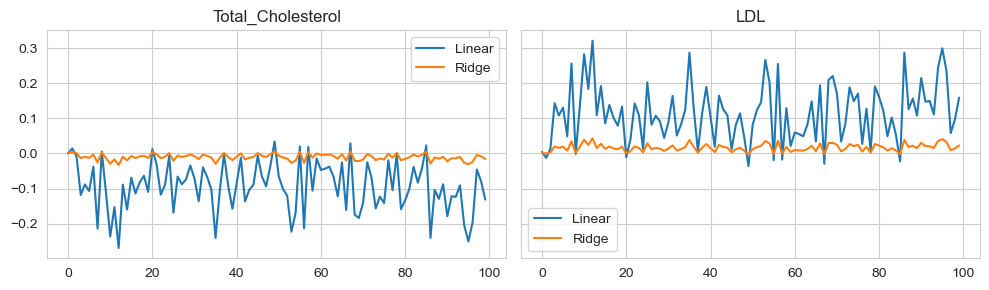

In [47]:
X = df.drop(columns = ['Heart_Attack_Risk'])
y = df['Heart_Attack_Risk']

coef_df_lr = pd.DataFrame(columns = df.columns[:-1])
coef_df_ridge = pd.DataFrame(columns = df.columns[:-1])

for k in range(100):
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)#, random_state=42)

    model = LinearRegression()
    model.fit(X_train, y_train)
    d = pd.DataFrame(index = df.columns[:-1], data = model.coef_).T
    coef_df_lr = pd.concat([coef_df_lr, d], ignore_index=True)
    
    model = Ridge()
    model.fit(X_train, y_train)
    d = pd.DataFrame(index = df.columns[:-1], data = model.coef_).T
    coef_df_ridge = pd.concat([coef_df_ridge, d], ignore_index=True)
    
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 3), sharey=True)

ax[0].plot(coef_df_lr['Total_Cholesterol'], color = 'C0', label = 'Linear')
ax[0].plot(coef_df_ridge['Total_Cholesterol'], color = 'C1', label = 'Ridge')
ax[0].set_title('Total_Cholesterol')
ax[0].legend()

ax[1].plot(coef_df_lr['LDL'], color = 'C0', label = 'Linear')
ax[1].plot(coef_df_ridge['LDL'], color = 'C1', label = 'Ridge')
ax[1].set_title('LDL')
ax[1].legend()

plt.tight_layout()
plt.show()

Вариативность признаков существенно понизилась. Это удобно с точки зрениия интерпретации результатов.

### 3.2. Исследование при помощи Lasso

#### Контекст

Институт космического мониторинга (ИКМ) собирает данные о космическом излучении — фоновом потоке галактических частиц высокой энергии. Измерения ведутся сетью наземных станций по всей России. Станции сгруппированы по федеральным округам (8 штук), но в сырых данных номер округа не указан — только код станции вида «буква + две цифры» (буква соответствует округу). Учёные хотят построить модель, предсказывающую средний суточный фон по всей России (таргет), на основе показаний всех станций.


#### Датасет
- Количество строк — 1095 (наблюдения за 3 года, по дням).

#### Предикторы

- A12, B05, C33, … — коды станций (всего 280). Каждая станция относится к одному из восьми округов по первой букве: A — Центральный, B — Северо-Западный, C — Южный, D — Северо-Кавказский, E — Приволжский, F — Уральский, G — Сибирский, H — Дальневосточный. Значение в ячейке — измеренный поток излучения (в условных единицах «импульс/см²·сек»), вещественное число от 0 до 100.


#### Таргет

- avg_radiation — средний фон по России за день.


#### Бизнес-задача

Применить Lasso-регрессию к данным измерений. Ожидается, что модель обнулит некоторое количество коэффициентов. Это позволит ИКМ сократить сеть мониторинга: вместо 300 станций оставить только ключевые, без потери точности прогноза среднего фона.

Читаем датасет:

In [48]:
df = pd.read_csv('data/radiation.csv')
df

,A00,A01,A02,A03,A04,A05,A06,A07,A08,A09,...,H32,H33,H34,H35,H36,H37,H38,H39,H40,avg_radiation
0,32.528477,27.385048,22.417111,24.653992,20.939551,13.097296,25.734696,26.721429,25.501119,20.319909,...,24.012911,20.295076,23.736337,19.384895,29.009298,21.169535,23.353533,25.206732,16.862367,24.899514
1,40.818313,30.858377,17.614985,22.233407,26.444649,27.087442,25.229716,25.173927,21.354779,24.229989,...,19.277967,26.258209,23.133368,29.032730,27.151828,17.268712,25.138863,37.367927,22.974309,30.360749
2,27.514096,28.280649,21.546758,28.905611,25.302267,35.235960,27.559542,34.812288,22.152091,34.376328,...,24.624200,33.715086,33.452159,31.986365,17.779162,22.930478,22.506662,34.756355,17.023553,30.230155
3,27.491580,27.444372,35.413773,28.191089,30.802189,27.687461,35.042004,37.768484,31.199277,36.050288,...,39.266994,29.346459,36.632729,23.182169,33.650881,42.186681,30.079486,29.057495,32.597626,30.376100
4,30.947026,28.395127,28.039605,35.674341,26.181676,39.068601,31.425193,39.633517,37.243921,31.112992,...,35.755347,29.339928,38.464340,30.970854,25.702076,36.420693,30.455993,39.674127,28.020508,29.277535
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1090,26.046094,43.105657,35.108547,31.695502,29.625323,23.740443,28.993125,31.108032,40.242901,40.278253,...,40.425337,32.052484,29.593915,27.562673,22.507615,38.088364,30.331149,30.995654,35.334044,32.582254
1091,22.034588,32.151190,29.167284,35.198359,38.604210,41.192048,30.304977,31.063036,23.780282,28.140918,...,29.423620,39.444421,37.027425,22.290893,33.386386,31.503446,33.045508,35.881529,31.887629,33.953341
1092,30.343545,31.163756,23.392818,31.809976,21.769748,33.548245,34.616281,32.027759,27.794010,22.515013,...,31.471946,34.628749,34.539790,28.821735,36.279915,28.669117,26.976870,28.682468,32.988690,31.809416
1093,34.672550,27.950216,31.193116,24.609034,24.704420,19.669508,28.535398,26.965125,30.230621,18.369555,...,23.261324,38.059859,26.983836,18.526995,23.046224,25.066409,22.301813,26.744922,20.986400,25.023872


#### 3.2.1. base-line модель
Сначала посмотрим, как ведет себя обычная линейная регессия, чтобы было с чем сравнивать Lasso-модель.

In [49]:
X = df.drop(columns = ['avg_radiation'])
y = df['avg_radiation']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)
y_train_pred_lr = lr.predict(X_train)
y_test_pred_lr = lr.predict(X_test)

print('r2_train =', round(r2_score(y_train, y_train_pred_lr), 4))
print('r2_test =', round(r2_score(y_test, y_test_pred_lr), 4))

r2_train = 0.7207
r2_test = 0.4593


Результаты так себе. И видно, что модель переобучена.

#### 3.2.2. Подбор параметра регуляризации для повышения скора

Теперь нас интересует, при каком уровне мягкого порога лассо будет давать лучшие результаты (и будет ли вообще). 

Мы варьируем параметр `alpha` в пределах от 0 до 5 с шагом 0.25. На каждом шаге мы производим 100 запусков, чтобы нивелировать случайное разбиение на train и test и усредняем метрики, полученные при этих запусках.

In [50]:
X = df.drop(columns = ['avg_radiation'])
y = df['avg_radiation']

score_train_lr = []
score_test_lr = []

score_train_lasso = []
score_test_lasso = []

for alpha in np.arange(0, 5, 0.25):

    r2_train_lr = []
    r2_test_lr = []

    r2_train_lasso = []
    r2_test_lasso = []
    not_null_lasso_coef = []


    for k in range(100):

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

        lr = LinearRegression()
        lr.fit(X_train, y_train)
        y_train_pred_lr = lr.predict(X_train)
        y_test_pred_lr = lr.predict(X_test)
        r2_train_lr.append(round(r2_score(y_train, y_train_pred_lr), 4))
        r2_test_lr.append(round(r2_score(y_test, y_test_pred_lr), 4))

        lasso = Lasso(alpha)
        lasso.fit(X_train, y_train)
        y_train_pred_lasso = lasso.predict(X_train)
        y_test_pred_lasso = lasso.predict(X_test)
        r2_train_lasso.append(round(r2_score(y_train, y_train_pred_lasso), 4))
        r2_test_lasso.append(round(r2_score(y_test, y_test_pred_lasso), 4))
        
    score_train_lr.append(round(np.array(r2_train_lr).mean(), 4))
    score_test_lr.append(round(np.array(r2_test_lr).mean(), 4))
    
    score_train_lasso.append(round(np.array(r2_train_lasso).mean(), 4))
    score_test_lasso.append(round(np.array(r2_test_lasso).mean(), 4))
    
    print('alpha =', round(alpha, 2))
    print('')
    print('Линейная регрессия')
    print('r2_train =', round(np.array(r2_train_lr).mean(), 4))
    print('r2_test =', round(np.array(r2_test_lr).mean(), 4))
    print('')
    print('Лассо')
    print('r2_train =', round(np.array(r2_train_lasso).mean(), 4))
    print('r2_test =', round(np.array(r2_test_lasso).mean(), 4))
    print('')

alpha = 0.0

Линейная регрессия
r2_train = 0.75
r2_test = 0.3167

Лассо
r2_train = 0.75
r2_test = 0.3167

alpha = 0.25

Линейная регрессия
r2_train = 0.7468
r2_test = 0.3532

Лассо
r2_train = 0.7022
r2_test = 0.5411

alpha = 0.5

Линейная регрессия
r2_train = 0.7456
r2_test = 0.3521

Лассо
r2_train = 0.6731
r2_test = 0.5548

alpha = 0.75

Линейная регрессия
r2_train = 0.7495
r2_test = 0.3341

Лассо
r2_train = 0.6691
r2_test = 0.5468

alpha = 1.0

Линейная регрессия
r2_train = 0.7489
r2_test = 0.3471

Лассо
r2_train = 0.6609
r2_test = 0.5394

alpha = 1.25

Линейная регрессия
r2_train = 0.7501
r2_test = 0.3394

Лассо
r2_train = 0.649
r2_test = 0.5274

alpha = 1.5

Линейная регрессия
r2_train = 0.7492
r2_test = 0.3403

Лассо
r2_train = 0.6343
r2_test = 0.5147

alpha = 1.75

Линейная регрессия
r2_train = 0.7479
r2_test = 0.3609

Лассо
r2_train = 0.6168
r2_test = 0.5119

alpha = 2.0

Линейная регрессия
r2_train = 0.7463
r2_test = 0.3679

Лассо
r2_train = 0.5941
r2_test = 0.5039

alpha = 2.2

И вот, что мы видим, после исполнения этого цикла:

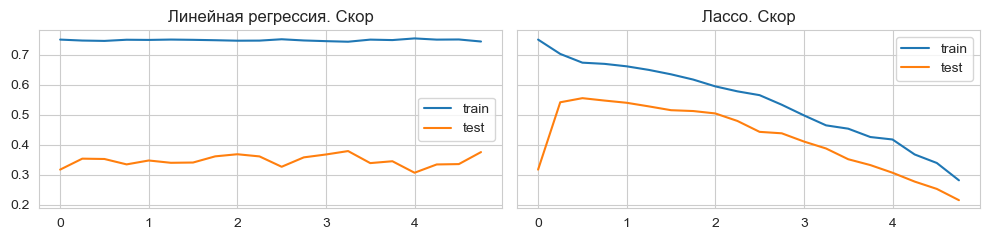

In [51]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 2.5), sharey=True)

ax[0].plot(np.arange(0, 5, 0.25), score_train_lr, color = 'C0', label = 'train')
ax[0].plot(np.arange(0, 5, 0.25), score_test_lr, color = 'C1', label = 'test')
ax[0].set_title('Линейная регрессия. Скор')
ax[0].legend()

ax[1].plot(np.arange(0, 5, 0.25), score_train_lasso, color = 'C0', label = 'train')
ax[1].plot(np.arange(0, 5, 0.25), score_test_lasso, color = 'C1', label = 'test')
ax[1].set_title('Лассо. Скор')
ax[1].legend()

plt.tight_layout()
plt.show()

Скор на test'е сначала повышается, потом, примерно в районе 0.5–0.8 достигает максимума, а потом начинает снижаться, причем после прохождения отметки 4 он становится даже ниже, чем у base-line.

#### 3.2.3. Подбор параметра регуляризации для определения значимых предикторов

Ну хорошо. А теперь посмотрим, что происходит с ненулевыми коэффициентами:

In [52]:
X = df.drop(columns = ['avg_radiation'])
y = df['avg_radiation']

n_coef_list = []

for alpha in np.arange(0, 5, 0.25):

    not_null_lasso_coef = []

    for k in range(100):

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

        lasso = Lasso(alpha)
        lasso.fit(X_train, y_train)
        y_train_pred_lasso = lasso.predict(X_train)
        y_test_pred_lasso = lasso.predict(X_test)
        
        not_null_lasso_coef.append(sum(abs(np.sign(lasso.coef_))))
    
    n_coef = round(np.array(not_null_lasso_coef).mean())
    n_coef_list.append(n_coef)
    
    print('alpha =', round(alpha, 2))
    print('n_coef =', n_coef)
    print('')

alpha = 0.0
n_coef = 280

alpha = 0.25
n_coef = 141

alpha = 0.5
n_coef = 104

alpha = 0.75
n_coef = 97

alpha = 1.0
n_coef = 93

alpha = 1.25
n_coef = 88

alpha = 1.5
n_coef = 84

alpha = 1.75
n_coef = 79

alpha = 2.0
n_coef = 73

alpha = 2.25
n_coef = 70

alpha = 2.5
n_coef = 64

alpha = 2.75
n_coef = 59

alpha = 3.0
n_coef = 55

alpha = 3.25
n_coef = 48

alpha = 3.5
n_coef = 46

alpha = 3.75
n_coef = 42

alpha = 4.0
n_coef = 38

alpha = 4.25
n_coef = 34

alpha = 4.5
n_coef = 29

alpha = 4.75
n_coef = 28



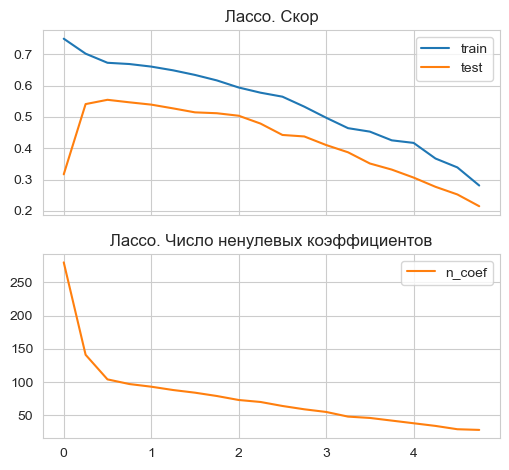

In [53]:
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(5.2, 4.8), sharex=True)

ax[0].plot(np.arange(0, 5, 0.25), score_train_lasso, color = 'C0', label = 'train')
ax[0].plot(np.arange(0, 5, 0.25), score_test_lasso, color = 'C1', label = 'test')
ax[0].set_title('Лассо. Скор')
ax[0].legend()

ax[1].plot(np.arange(0, 5, 0.25), n_coef_list, color = 'C1', label = 'n_coef')
ax[1].set_title('Лассо. Число ненулевых коэффициентов')
ax[1].legend()

plt.tight_layout()
plt.show()

Что мы видим теперь. Число ненулевых коэффициентов все время падает. Но сначала падение происходит быстро, а потом — медленно. А смена тренда (с быстрого на медленный) происходит ровно там же, где скор Lasso достигал своего максимума.

Это не случайность.

Первая кратинка говорит нам: на уровне примерно 0.5–0.8 мы избавились от основного шума в данных, поэтому скор на test'е вырос (модель на train'е перестала подстраиваться под шум). А дальше начинаем резать полезные предикторы. Поэтому после этого скор начинает падать.

Вторая картинка говорит нам то же самое: до уровня примерно 0.5–0.8 мы избавлялись от очевидного шума в данных, поэтому обнуление шло быстро. А после шум стал менее очевидным (это были уже полезные данные, а не шум). Мы продолжили избавляться от предикторов, но дело пошло гораздо медленнее.

#### 3.2.4. Практические выводы

Исследование показало, что можно избавиться от большей части станций: оставить примерно 100 из 280. При этом точность прогноза не пострадает.